# GoTriple metadata cleaning — strategies, queries and timings

Two problems, two sections:

- **[1. Authors](#1-authors)** — recovering broken names, and deciding which profiles are the same person
- **[2. Licenses](#2-licenses)** — recovering a usable license for documents that have none

Every subsection shows the same three things:

1. **the schema** — what the strategy tries, in order, and where it gives up
2. **the Elasticsearch query actually executed** — captured from `es_helpers.QUERY_LOG`, never retyped
3. **a live run**, timed

Everything runs against `triple-profiles-prod` / `triple-documents-prod` through
Elasticsearch. Credentials come from `.env`; see `src/es_helpers.py`.

> The three constants in the next cell drive everything. Samples are small so the
> notebook finishes in minutes; raise them to scale —
> cost is linear in the number of records, except where noted in §3.

In [30]:
import contextlib, io, json, time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.es_helpers import last_query
from src import pipelines
from src.functions_license import build_license_query, count_elastic_documents
from src.functions_name import count_elastic_authors, NAME_FILTER_QUERIES

# ============================================================================
# INITIAL PARAMETERS - change these, re-run, everything below follows
# ============================================================================
AUTHOR_NAME     = "Wang, Y."   # the name searched in the disambiguation subsection (1.4)
AUTHOR_SAMPLE   = 100          # author profiles to pull per subsection  (1.1 - 1.4)
DOCUMENT_SAMPLE = 100         # documents to pull for license recovery  (2.3)
# ============================================================================

TIMINGS = {}
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .3})
OK, BAD, ALT = "#4c72b0", "#c44e52", "#55a868"


@contextlib.contextmanager
def timed(label):
    """Record wall-clock time so §3 is measured, not guessed."""
    start = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - start
    print(f"[{label}] {TIMINGS[label]:.1f}s")


def quietly(function, *args, **kwargs):
    """Run a pipeline stage, capturing its per-record chatter."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        result = function(*args, **kwargs)
    return result, buffer.getvalue()


def digest(output, keep=("->", "*", "---")):
    """Print only the summary lines from captured pipeline output."""
    for line in output.splitlines():
        if line.strip().startswith(keep):
            print(line)


def params(**values):
    """Print the parameters a run was given, so every result is self-describing."""
    width = max(len(k) for k in values)
    print("parameters")
    for key, value in values.items():
        print(f"  {key.replace('_', ' '):<{width}} : {value}")
    print()


def show_query(index_contains, title="query executed"):
    entry = last_query(index_contains)
    print(f"{title} — index: {entry['index']}")
    print(json.dumps(entry["body"], indent=2, ensure_ascii=False))


def show_markdown(text):
    """Render a table built from the numbers this run produced. Nothing quoted in
    the prose below is typed in, so it cannot disagree with the cell above it."""
    display(Markdown(text))


def stage_outcomes(rows, title, note=None):
    """The bar chart every stage ends with: one bar per outcome, in the order
    (solved, settled, open). Each bar carries its own count and share, so the
    colour only reinforces the label rather than carrying it."""
    palette = {"solved": ALT, "settled": OK, "open": BAD}
    total = sum(int(row[1]) for row in rows) or 1
    rows = [row for row in rows if int(row[1])] or rows   # an empty outcome is not a bar
    labels = [row[0] for row in rows]
    values = [int(row[1]) for row in rows]

    fig, ax = plt.subplots(figsize=(9, .5 * len(rows) + 1.3))
    ax.barh(labels[::-1], values[::-1], height=.55,
            color=[palette[row[2]] for row in rows][::-1])
    for position, value in enumerate(values[::-1]):
        ax.text(value + total * .012, position, f"{value:,}   {value / total:.0%}",
                va="center", color="#52514e")

    ax.set_xlim(0, total * 1.2)
    ax.set_xticks([])
    ax.grid(False)
    ax.set_title(title, loc="left", fontweight="bold", pad=20 if note else 10)
    if note:
        ax.text(0, 1.03, note, transform=ax.transAxes, color="#8a8a8a", fontsize=9, va="bottom")
    plt.tight_layout(); plt.show()


---
# 1. Authors

`triple-profiles-prod` holds the author profiles. Two unrelated problems live here.

**A name can be broken in several distinct ways**, and they do not respond to the
same treatment at all:

In [31]:
# Counted from the index rather than typed in, so the table cannot drift from it.
NAME_PROBLEMS = [("1.1", "an ORCID sits inside the name",   "orcid", "almost all recoverable"),
                 ("1.2", "the name is empty",               "empty", "rarely recoverable"),
                 ("1.3", "the name is a URL or bare digits", "junk", "URLs no; bare numbers are repository ids")]

populations = {key: count_elastic_authors(name_filter=key) for _, _, key, _ in NAME_PROBLEMS}

show_markdown(
    f"`triple-profiles-prod` holds **{count_elastic_authors():,} author profiles**. Each subsection "
    f"below pulls `AUTHOR_SAMPLE` = **{AUTHOR_SAMPLE}** of the profiles it selects.\n\n"
    "| §  | problem | profiles | this run | outlook |\n"
    "|----|---------|---------:|---------:|---------|\n"
    + "".join(f"| {section} | {problem} | {populations[key]:,} | "
             f"{min(AUTHOR_SAMPLE, populations[key]):,} | {outlook} |\n"
             for section, problem, key, outlook in NAME_PROBLEMS))

`triple-profiles-prod` holds **23,832,186 author profiles**. Each subsection below pulls `AUTHOR_SAMPLE` = **100** of the profiles it selects.

| §  | problem | profiles | this run | outlook |
|----|---------|---------:|---------:|---------|
| 1.1 | an ORCID sits inside the name | 2,871 | 100 | almost all recoverable |
| 1.2 | the name is empty | 2,039 | 100 | rarely recoverable |
| 1.3 | the name is a URL or bare digits | 1,832 | 100 | URLs no; bare numbers are repository ids |


**Separately**, many profiles that *have* a fine name are duplicates of each
other (§1.4). That is a different question — not *what is this person called*
but *are these records the same person* — and it is solved by clustering, not
by lookups.

## 1.1 Names with an ORCID inside

The highest-yield repair in the project. The field holds the identifier, alone
or stuck onto a real name:

```
 '0000-0002-1588-0683'
 'Ana Morales, 0000-0001-6969-2883'
 'https://orcid.org/0000-0003-4140-8101'
 'Ardeshir Bazrkar orcid'                 ← the word survived, the id did not
```

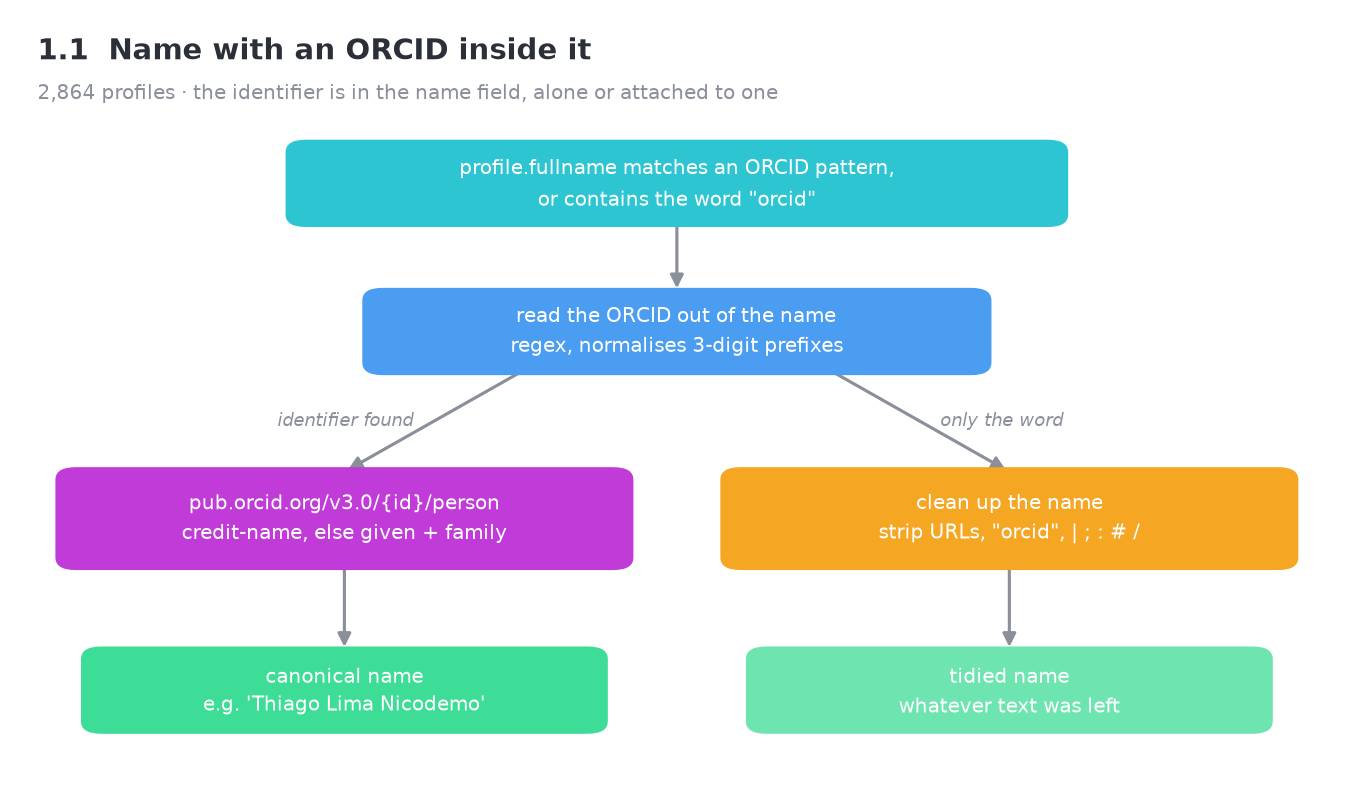

**Checking the documents index first would be wasted work.** The document holds
the *identical* broken string — GoTriple copies the name from it:

```
profile : 'Ana Morales, 0000-0001-6969-2883'
document: ['Ana Morales, 0000-0001-6969-2883']
```

ORCID is the only source that actually knows the person's name, so the pipeline
goes straight there whenever an identifier is present.

In [32]:
print(f"profiles with an ORCID in the name: {count_elastic_authors(name_filter='orcid'):,}")
print(json.dumps(NAME_FILTER_QUERIES["orcid"], indent=2))

profiles with an ORCID in the name: 2,871
{
  "bool": {
    "should": [
      {
        "regexp": {
          "fullname.keyword": ".*[0-9]{4}-[0-9]{4}-[0-9]{4}-[0-9X]{4}.*"
        }
      },
      {
        "match": {
          "fullname": "orcid"
        }
      }
    ],
    "minimum_should_match": 1
  }
}


In [33]:
params(task="orcid_names", index="triple-profiles-prod", source="elastic",
       selection="fullname matches an ORCID pattern, or contains 'orcid'",
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='orcid'):,}")

with timed("1.1 names: orcid inside"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="orcid_names")

show_query("profiles", "\nselection query")
print()
digest(output)

parameters
  task              : orcid_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname matches an ORCID pattern, or contains 'orcid'
  records requested : 100
  population        : 2,871

[1.1 names: orcid inside] 14.5s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "bool": {
      "should": [
        {
          "regexp": {
            "fullname.keyword": ".*[0-9]{4}-[0-9]{4}-[0-9]{4}-[0-9X]{4}.*"
          }
        },
        {
          "match": {
            "fullname": "orcid"
          }
        }
      ],
      "minimum_should_match": 1
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ]
}

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'orcid only': 67, 'orcid embedded in name': 32, 'stray orcid word': 1}
--- Name recovery by problem ---
     * orcid embedded in name     32/32   recovered
     * orcid only                 67/67   recovered
     * stray orcid

In [34]:
orcid_names = pd.read_excel("data/output/authors_orcid_names_elastic.xlsx")
print(orcid_names[["fullname", "fullname_fix", "name_source"]].head(8).to_string(index=False))

                                                                                                   fullname                                                                                           fullname_fix      name_source
                                                                           Ana Morales, 0000-0001-6969-2883                                                                                            Ana Morales        orcid api
                                                                          Anne Lutomia, 0000-0001-6029-8783                                                                                   Anne Namatsi Lutomia        orcid api
                                                                        Andrea Demaria, 0000-0002-5450-0444                                                                                      Andrea L. Demaria        orcid api
                                                                              0000-0002-

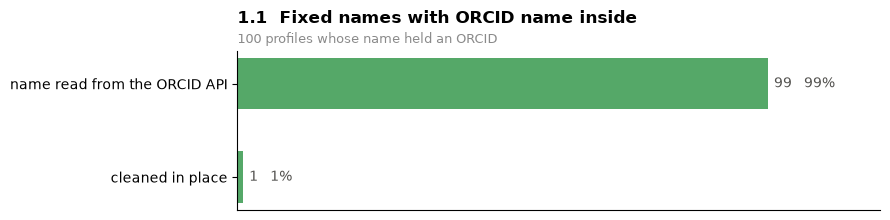

In [35]:
sources = pd.read_excel("data/output/authors_orcid_names_elastic.xlsx")["name_source"].value_counts()
stage_outcomes([
    ("name read from the ORCID API", sources.get("orcid api", 0), "solved"),
    ("cleaned in place", sources.get("cleaned in place", 0), "solved"),
    ("still broken", sources.get("not recovered", 0), "open"),
], "1.1  Fixed names with ORCID name inside", f"{sources.sum():,} profiles whose name held an ORCID")

## 1.2 Empty names

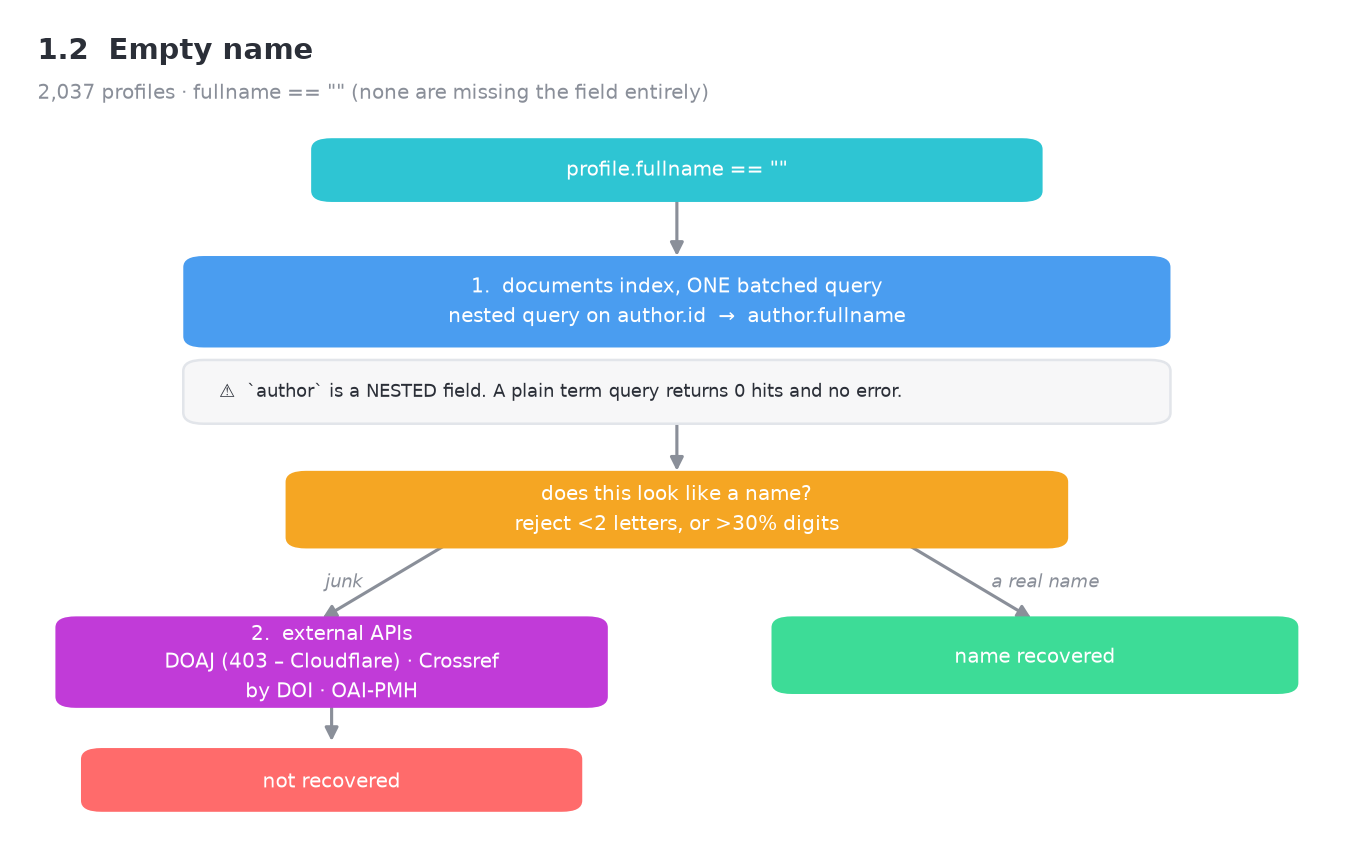

**Expect this to fail, and that is the finding.** Measured yield over 300 blank
profiles: **13 (4.3%)** — and most of those are not people:
`(Eds)`, `(sous la dir. de)`, `(pdf Formatında)`, `Author`.

These names are empty *because the source metadata was junk*. GoTriple blanked
them deliberately, and the document they came from still holds that same junk.

In [36]:
print(f"profiles with an empty name: {count_elastic_authors(name_filter='empty'):,}")
print(json.dumps(NAME_FILTER_QUERIES["empty"], indent=2))

profiles with an empty name: 2,039
{
  "term": {
    "fullname.keyword": ""
  }
}


In [37]:
params(task="empty_names", index="triple-profiles-prod", source="elastic",
       selection='fullname.keyword == ""',
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='empty'):,}")

with timed("1.2 names: empty"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="empty_names")

show_query("profiles", "\nselection query")
print()
digest(output)

parameters
  task              : empty_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname.keyword == ""
  records requested : 100
  population        : 2,039

[1.2 names: empty] 35.1s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "term": {
      "fullname.keyword": ""
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ]
}

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'empty': 100}
-> 0/100 recovered from the documents index
--- Name recovery by problem ---
     * empty                       0/100  recovered
-> Author data saved to '/Users/paulopiimenta/projects/lumen/lumen-metadata-t43/data/output/authors_empty_names_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candidates sharing a resolved Name : 0 records (across 0 unique clusters)
--- Disambiguation Results ---
------------------------------------------------------------
-> F

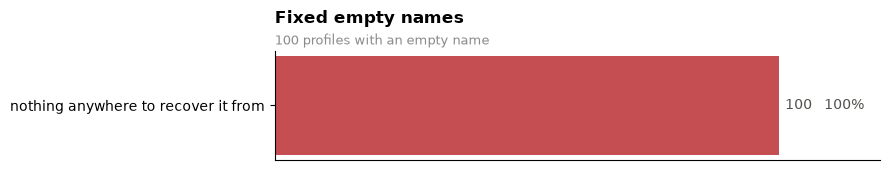

In [38]:
sources = pd.read_excel("data/output/authors_empty_names_elastic.xlsx")["name_source"].value_counts()
stage_outcomes([
    ("name found in the documents index", sources.get("documents index", 0), "solved"),
    ("nothing anywhere to recover it from", sources.get("not recovered", 0), "open"),
], "Fixed empty names", f"{sources.sum():,} profiles with an empty name")

## 1.3 URL or bare-digit names

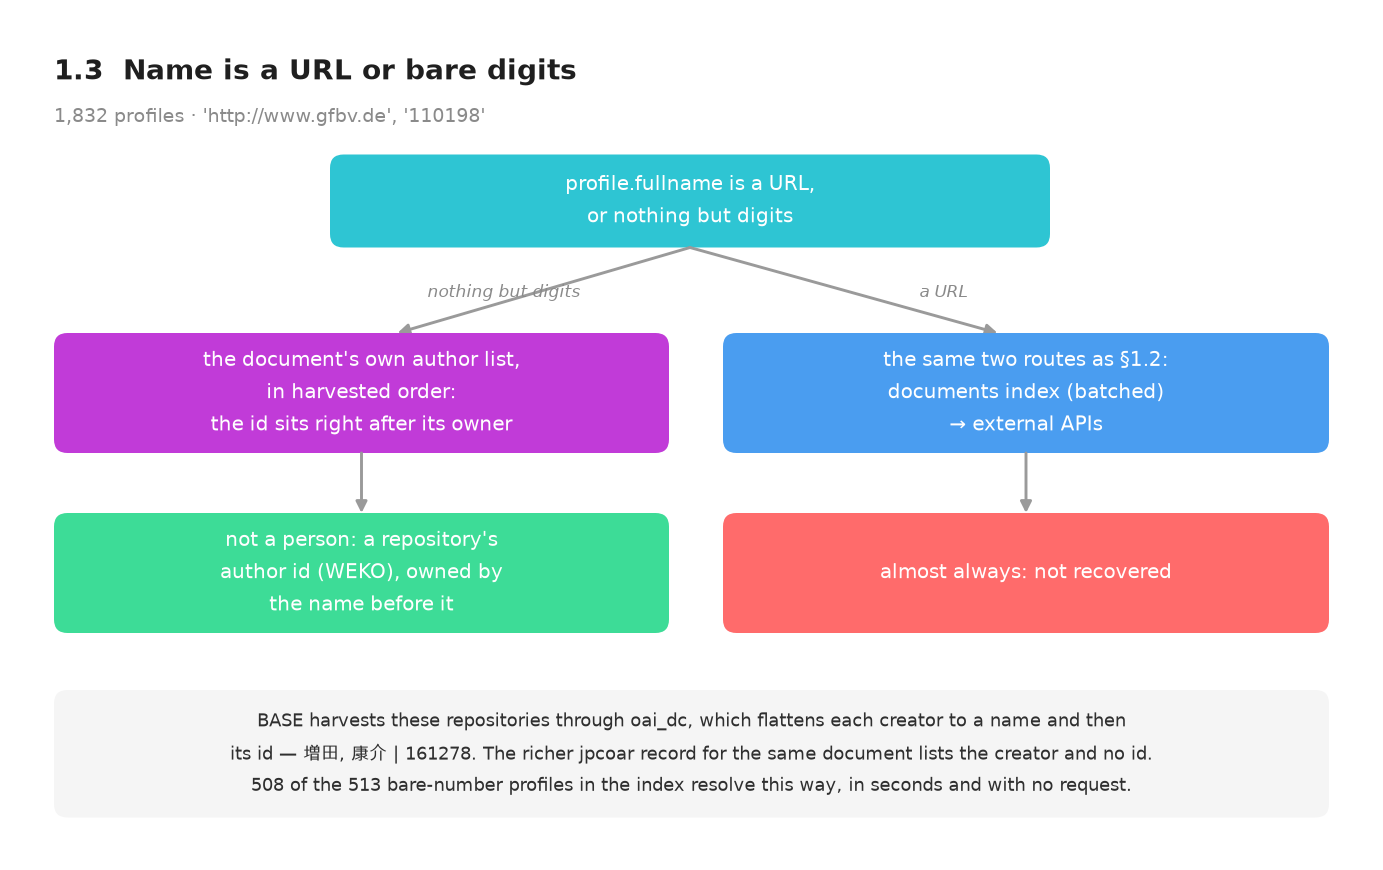

A URL is not a person — and neither is a bare number, but for a different reason.
**Every bare-number name in the index is a repository's own author id.** WEKO
repositories (u-tokyo, niigata) publish that id as a second `dc:creator`, right
after the creator it belongs to; BASE harvests the flattened `oai_dc` view, so
GoTriple mints a profile for it:

```
jpcoar   creatorName: 増田, 康介                     ← one creator
oai_dc   dc:creator : 増田, 康介 | 161278            ← name, then her id
```

There is no name to recover for these, so the pipeline stops asking. The pairing
survives into the documents index, where `author` keeps the harvested order, and
`resolve_repository_ids()` reads the owner off the entry before the id — no
request to anyone. They are reported as **repository id**, with the owner in
`belongs_to`, and never counted as a recovered name.

The URLs are the genuine remainder: they take the same two routes as §1.2 and
almost always come back empty.

In [39]:
print(f"URL / numeric names: {count_elastic_authors(name_filter='junk'):,}")
print(json.dumps(NAME_FILTER_QUERIES["junk"], indent=2))

params(task="junk_names", index="triple-profiles-prod", source="elastic",
       selection="fullname is a URL or bare digits",
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='junk'):,}")

with timed("1.3 names: url / numeric"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="junk_names")
print()
digest(output)

URL / numeric names: 1,832
{
  "bool": {
    "should": [
      {
        "match": {
          "fullname": "http"
        }
      },
      {
        "regexp": {
          "fullname.keyword": "[0-9]+"
        }
      }
    ],
    "minimum_should_match": 1
  }
}
parameters
  task              : junk_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname is a URL or bare digits
  records requested : 100
  population        : 1,832

[1.3 names: url / numeric] 8.8s

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'numeric': 100}
-> 100/100 numeric names are a repository's own author id, not a person
--- Name recovery by problem ---
     * numeric                     0/100  recovered  (100 are repository ids, not people)
-> Author data saved to '/Users/paulopiimenta/projects/lumen/lumen-metadata-t43/data/output/authors_junk_names_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candid

In [40]:
import re

from src.functions_name import resolve_repository_ids
from src.es_helpers import es_search, DOCUMENTS_INDEX

junk = pd.read_excel("data/output/authors_junk_names_elastic.xlsx")
digits = junk[junk["fullname"].astype(str).str.fullmatch(r"\d+")].copy()
digits["author_of"] = digits["author_of"].map(
    lambda value: re.findall(r"'([^']*)'", value) if isinstance(value, str) else [])

with timed("1.3 repository ids"):
    owners = resolve_repository_ids(digits.to_dict("records"))

# the mechanism, on one document: the id sits directly after the name it belongs to
example = digits.iloc[0]
document = es_search({"size": 1, "query": {"term": {"id": example["author_of"][0]}},
                      "_source": ["id", "author"]}, index=DOCUMENTS_INDEX)["hits"]["hits"][0]

show_markdown(
    f"**{len(owners)} of {len(digits)} bare-number profiles are a repository id**, "
    f"resolved from the documents index alone — no ORCID call, no scraping.\n\n"
    f"`{document['_source']['id']}` stores its authors in the order they were harvested:\n\n"
    + "".join(f"- {'**' + str(a['fullname']) + '**  ← the id' if str(a['fullname']).isdigit() else a['fullname']}\n"
             for a in document["_source"]["author"])
    + "\n| bare number | belongs to |\n|---|---|\n"
    + "".join(f"| `{row['fullname']}` | {owners.get(str(row['id']), '—')} |\n"
             for _, row in digits.head(5).iterrows()))

[1.3 repository ids] 1.4s


**100 of 100 bare-number profiles are a repository id**, resolved from the documents index alone — no ORCID call, no scraping.

`ftunivtokyo:oai:repository.dl.itc.u-tokyo.ac.jp:00032435` stores its authors in the order they were harvested:

- 森田, 裕一
- **123591**  ← the id
- 酒井, 慎一
- **123592**  ← the id
- 中川, 茂樹
- **123593**  ← the id
- 笠原, 敬司
- **123594**  ← the id
- 平田, 直
- **123595**  ← the id
- 鏡, 弘道
- **123596**  ← the id
- 加藤, 拓弥
- **123597**  ← the id
- 佐藤, 峰司
- **123598**  ← the id

| bare number | belongs to |
|---|---|
| `123598` | 佐藤, 峰司 |
| `107580` | 久本, 貴志 |
| `48473` | 蘆田, 一郎 |
| `69763` | ハスバガン |
| `161278` | 増田, 康介 |


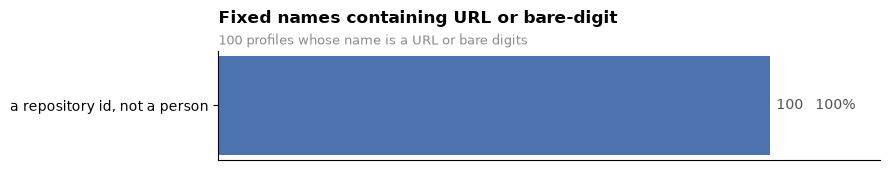

In [41]:
sources = pd.read_excel("data/output/authors_junk_names_elastic.xlsx")["name_source"].value_counts()
recovered = sum(sources.get(key, 0) for key in ("documents index", "orcid api", "cleaned in place"))
stage_outcomes([
    ("name recovered", recovered, "solved"),
    ("a repository id, not a person", sources.get("repository id", 0), "settled"),
    ("already a usable name", sources.get("unchanged", 0), "settled"),
    ("still broken", sources.get("not recovered", 0), "open"),
], "Fixed names containing URL or bare-digit", f"{sources.sum():,} profiles whose name is a URL or bare digits")

## 1.4 Disambiguation

Not *what is this person called* but *are these records the same person*. Split
into two phases so the second one is deterministic.

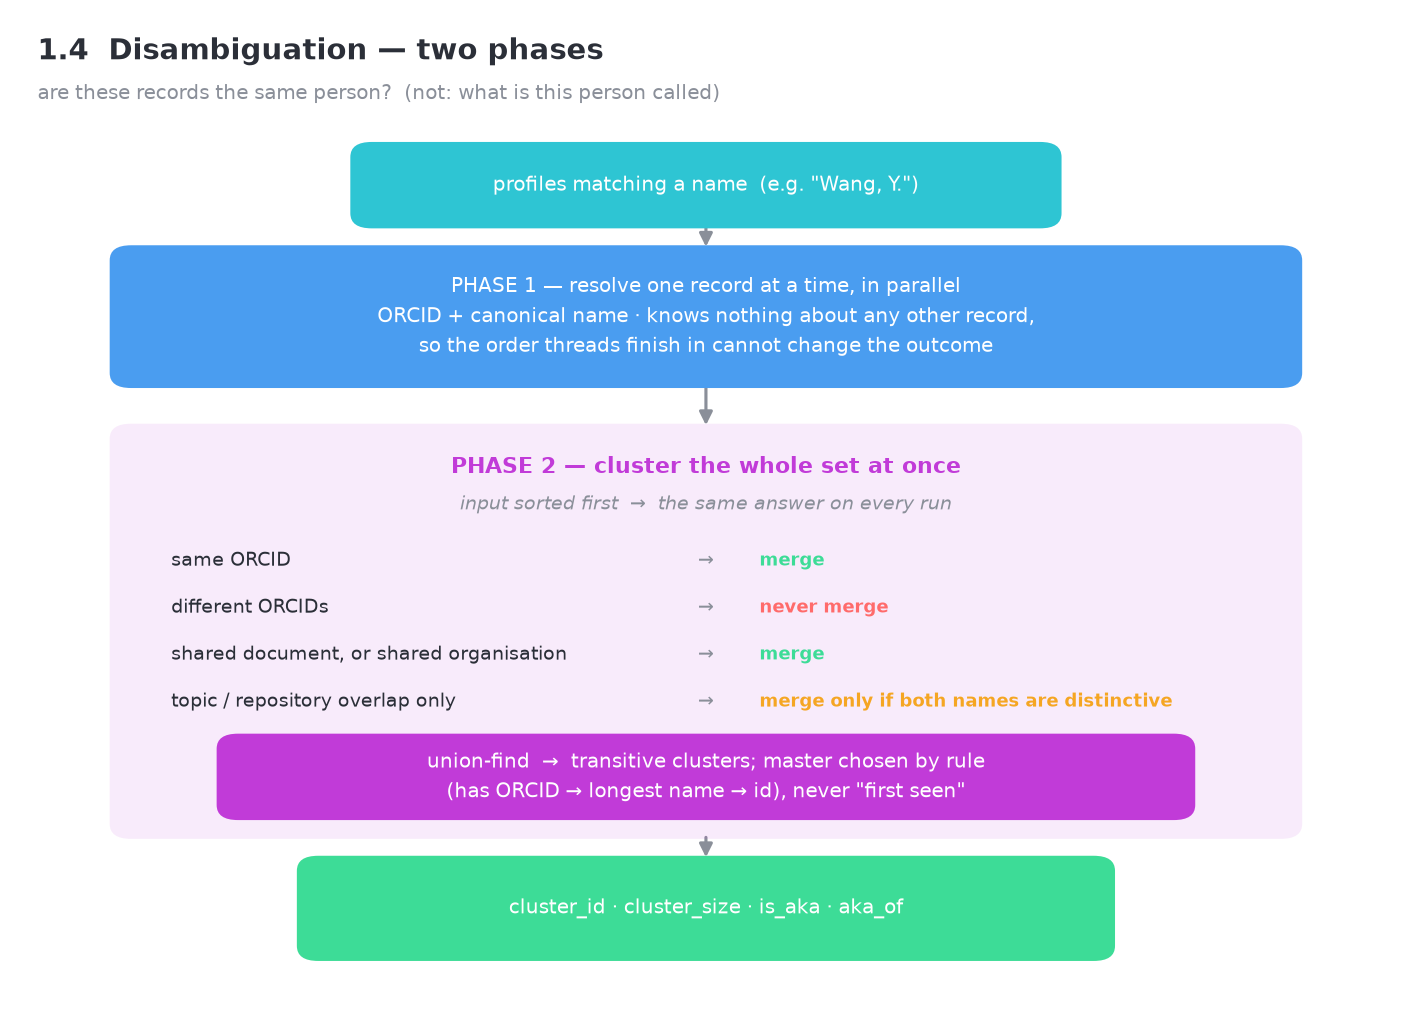

Why the "distinctive name" rule exists: 40 profiles named `Wang, Y.` share
**0 documents across 780 pairs**, but 264 of those pairs share a coarse topic
like `geo`. Merging on that evidence conflates strangers.

In [42]:
print(f"profiles matching {AUTHOR_NAME!r}: {count_elastic_authors(query=AUTHOR_NAME):,}")

params(task="disambiguate", strategy="cluster", index="triple-profiles-prod", source="elastic",
       name_searched=AUTHOR_NAME, records_requested=AUTHOR_SAMPLE,
       population=f"{count_elastic_authors(query=AUTHOR_NAME):,}")

with timed("1.4 disambiguation: cluster"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE), "q": AUTHOR_NAME},
                        source="elastic", task="disambiguate", strategy="cluster")

show_query("profiles", "\nselection query")
print()
digest(output)

profiles matching 'Wang, Y.': 2,554
parameters
  task              : disambiguate
  strategy          : cluster
  index             : triple-profiles-prod
  source            : elastic
  name searched     : Wang, Y.
  records requested : 100
  population        : 2,554

[1.4 disambiguation: cluster] 43.2s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "match": {
      "fullname": {
        "query": "Wang, Y.",
        "operator": "and"
      }
    }
  },
  "sort": [
    {
      "_score": "desc"
    },
    {
      "id": "asc"
    }
  ],
  "from": 0
}

--- STARTING AUTHOR NAME PIPELINE ---
-> 100 distinct identities, 0 records merged into them
-> Author data saved to '/Users/paulopiimenta/projects/lumen/lumen-metadata-t43/data/output/authors_disambiguation_cluster_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candidates sharing a resolved Name : 95 records (across 4 unique clusters)
     * Master Name: Gershtein, Y.

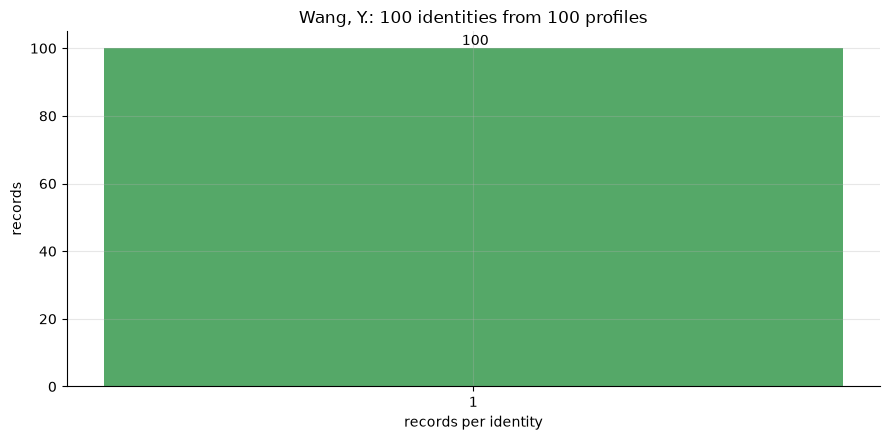

In [43]:
clustered = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
sizes = clustered["cluster_size"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(sizes.index.astype(str), sizes.values, color=ALT)
ax.set_xlabel("records per identity"); ax.set_ylabel("records")
ax.set_title(f"{AUTHOR_NAME}: {clustered['cluster_id'].nunique()} identities "
             f"from {len(clustered)} profiles")
for i, v in enumerate(sizes.values):
    ax.text(i, v, f" {v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

In [44]:
sizes = clustered["cluster_size"].value_counts().sort_index()
singletons = int(sizes.get(1, 0))
print(f"cluster sizes for {AUTHOR_NAME!r}:")
for size, count in sizes.items():
    print(f"  {count:>4} records sit in a cluster of {size}")
print(f"\n{singletons} of {len(clustered)} records are a cluster of one -> "
      f"{'no two profiles were judged the same person' if singletons == len(clustered) else 'some merged'}")
print(f"distinct identities: {clustered['cluster_id'].nunique()}")

cluster sizes for 'Wang, Y.':
   100 records sit in a cluster of 1

100 of 100 records are a cluster of one -> no two profiles were judged the same person
distinct identities: 100


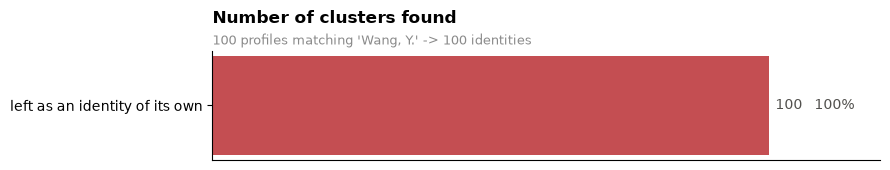

In [45]:
identities = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
together = int((identities["cluster_size"] > 1).sum())
stage_outcomes([
    ("sharing an identity with another record", together, "solved"),
    ("left as an identity of its own", len(identities) - together, "open"),
], "Number of clusters found",
   f"{len(identities):,} profiles matching {AUTHOR_NAME!r} -> "
   f"{identities['cluster_id'].nunique():,} identities")

In [46]:
import itertools
import re
from collections import defaultdict

records    = len(clustered)
identities = clustered["cluster_id"].nunique()
merged     = records - identities
pairs      = records * (records - 1) // 2
with_orcid = int(clustered["id_fix"].notna().sum())
variants   = clustered["fullname"].nunique()
population = count_elastic_authors(query=AUTHOR_NAME)


def document_ids(value):
    """`author_of` is stored as a stringified list, and Excel truncates one longer
    than 32,767 characters mid-item - so read the ids out with a regex, which does
    not care where the list was cut, rather than parsing it as Python."""
    return set(re.findall(r"'([^']*)'", value)) if isinstance(value, str) else set()


# Index by document, so the pairs that share one fall out directly instead of
# every pair of records being compared - that comparison is quadratic.
holders = defaultdict(set)
for position, ids in enumerate(clustered["author_of"].map(document_ids)):
    for document in ids:
        holders[document].add(position)

sharing = len({pair for shared in holders.values() if len(shared) > 1
               for pair in itertools.combinations(sorted(shared), 2)})

headline = (f"**{merged} merged means no cluster was formed.** Every one of the {records} profiles is its "
            "own identity — a cluster of size 1. Clustering did not fail to run; it ran and found nothing "
            "that would justify joining any two records:"
            if merged == 0 else
            f"**{merged} of {records} records merged**, leaving {identities} identities. The evidence the "
            "rules had to go on:")

show_markdown(f"""### Reading that result

{headline}

| evidence | present? |
|---|---|
| same ORCID | {with_orcid} of the {records} profiles carry one |
| shared document | {sharing:,} of {pairs:,} pairs share one |
| shared organisation | the profiles index has no `current_organization` field |
| distinctive name + topic overlap | the name is initials-only, so this rule is deliberately blocked |

The only thing these records have in common is a surname and an initial, in {variants} spelling
variants, shared by {population:,} profiles. That is not evidence of identity.
""")

### Reading that result

**0 merged means no cluster was formed.** Every one of the 100 profiles is its own identity — a cluster of size 1. Clustering did not fail to run; it ran and found nothing that would justify joining any two records:

| evidence | present? |
|---|---|
| same ORCID | 0 of the 100 profiles carry one |
| shared document | 0 of 4,950 pairs share one |
| shared organisation | the profiles index has no `current_organization` field |
| distinctive name + topic overlap | the name is initials-only, so this rule is deliberately blocked |

The only thing these records have in common is a surname and an initial, in 7 spelling
variants, shared by 2,554 profiles. That is not evidence of identity.


### 1.4.1 How heuristic works

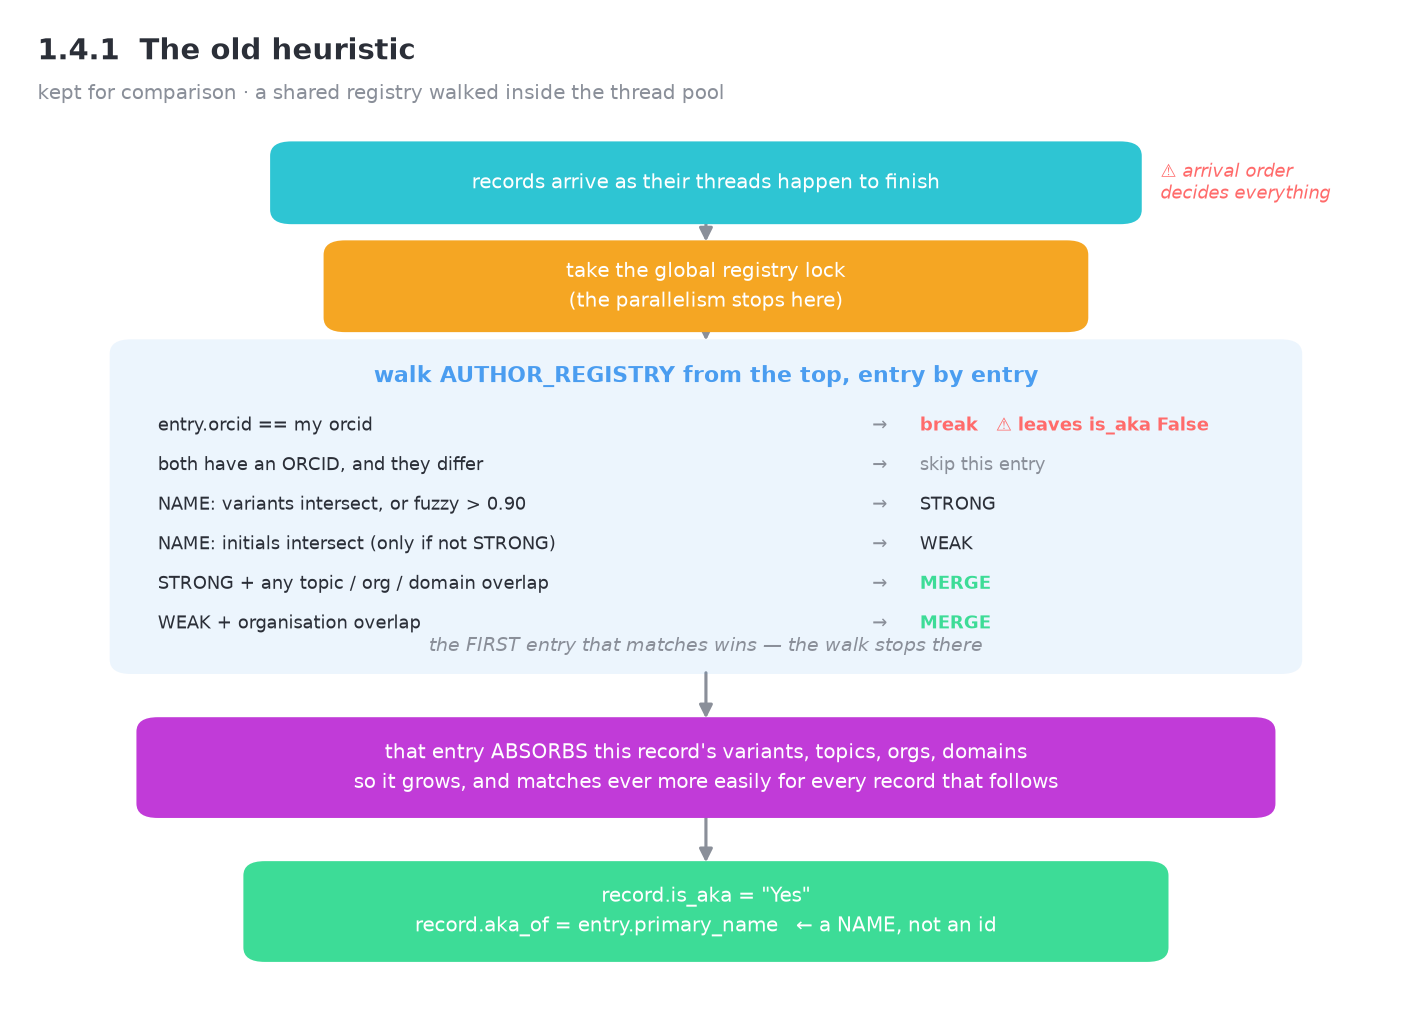

Four consequences follow from that shape:

**1. The answer depends on arrival order.** Records are consumed as futures
complete, so network timing decides which record becomes a master and which gets
absorbed. The same input produced 7 identities on one run and 8 on the next.

**2. Groups snowball.** Every merge widens the entry's name variants and context
sets, so an entry that has absorbed a few records matches almost anything that
follows. That is how 95 of 100 profiles ended up behind one master.

**3. Identity is recorded as a name.** `aka_of` holds `entry.primary_name`, so two
distinct groups whose masters share a name become indistinguishable downstream —
measured on this data: 9 groups, only 5 distinct master names, 5 of the 9 all
called `Wang, Y.`

**4. The ORCID shortcut does not merge anything.** Its body was left as
`# ... [existing shortcut code] ...` followed by `break`. Breaking leaves
`is_aka` False, so the record falls past the loop into
`if not is_aka: AUTHOR_REGISTRY.append(...)` and is registered as a **new**
author. The strongest identity evidence available is silently discarded — the
next cell demonstrates it.

In [47]:
import src.functions_name as fn

# Two records, same ORCID. Nothing is more definitive than that.
same_orcid = [
    {"fullname": "J. Smith 0000-0002-1825-0097", "author_of": [], "topic": ["phys"],
     "current_organization": []},
    {"fullname": "John Smith 0000-0002-1825-0097", "author_of": [], "topic": ["phys"],
     "current_organization": []},
]

fn.AUTHOR_REGISTRY.clear()
resolved, _ = quietly(lambda rs: [fn.process_author(dict(r)) for r in rs], same_orcid)

for record in resolved:
    print(f"{record['fullname_fix']:20} orcid={record['id_fix']}  is_aka={record['is_aka']}")
print(f"registry entries: {len(fn.AUTHOR_REGISTRY)} (should be 1)")
print()
print("Both records resolve to the same person via the same ORCID, and the")
print("heuristic still files them as two separate identities. cluster_authors()")
print("merges them - it is the first rule in the evidence table above.")

Josiah Carberry      orcid=0000-0002-1825-0097  is_aka=No
Josiah Carberry      orcid=0000-0002-1825-0097  is_aka=No
registry entries: 2 (should be 1)

Both records resolve to the same person via the same ORCID, and the
heuristic still files them as two separate identities. cluster_authors()
merges them - it is the first rule in the evidence table above.


### 1.4.2 The same data through the old heuristic

Kept for comparison. It walks a shared registry *inside* the thread pool, so the
answer depends on which future finishes first — run it twice and the counts move.

In [ ]:
import random
import src.functions_name as fn
from src.functions_name import fetch_elastic_authors

sample = fetch_elastic_authors(size=str(AUTHOR_SAMPLE), query=AUTHOR_NAME)

params(task="disambiguate", strategy="heuristic", index="triple-profiles-prod", source="elastic",
       name_searched=AUTHOR_NAME, records=len(sample), runs="2 (different input orders)")

heuristic_runs, heuristic_groups = {}, {}

with timed("1.4 disambiguation: heuristic"):
    for seed in (1, 2):
        fn.AUTHOR_REGISTRY.clear()
        shuffled = [dict(a) for a in sample]
        random.Random(seed).shuffle(shuffled)
        quietly(lambda rs: [fn.process_author(r) for r in rs], shuffled)
        heuristic_runs[seed] = shuffled
        heuristic_groups[seed] = len(fn.AUTHOR_REGISTRY)  # the real number of groups
        merged = sum(1 for r in shuffled if r.get("is_aka") == "Yes")
        print(f"  run {seed}: {len(shuffled) - merged} identities, {merged} merged")

parameters
  task          : disambiguate
  strategy      : heuristic
  index         : triple-profiles-prod
  source        : elastic
  name searched : Wang, Y.
  records       : 100
  runs          : 2 (different input orders)

  run 1: 9 identities, 91 merged


### 1.4.3 Clusters as bubbles

One bubble per **cluster actually formed** — a group of two or more profile
records judged to be the same person. Singletons are left out: a profile that
merged with nothing is not a cluster, and 100 identical dots say nothing. The
title carries the count that matters instead: how many of the profiles ended up
inside a cluster at all.

**The heuristic row is approximate, and that is itself a finding.** Clustering
emits a `cluster_id`, so its bubbles are exact. The heuristic only records the
master's *name* in `aka_of` — two groups whose masters share a name cannot be
told apart, so its bubble count comes out *lower* than the number of groups it
really formed. An identity key has to be an id, not a name.

In [ ]:
import collections
import numpy as np
from matplotlib.lines import Line2D

PALETTE = ["#2ec5d3", "#c13bd8", "#f5a623", "#4a9df0", "#7ed957", "#ff6b6b",
           "#9b6bff", "#3ddc97", "#ff9f43", "#5f27cd"]


def clusters_from_clustering(frame):
    """(label, size) per cluster_id - exact, because the id is real."""
    records = frame.to_dict("records")
    sizes = collections.Counter(r["cluster_id"] for r in records)
    masters = {r["cluster_id"]: (r.get("fullname_fix") or r.get("fullname"))
               for r in records if r.get("is_aka") == "No"}
    return [(str(masters.get(cid, cid)), n) for cid, n in sizes.most_common()]


def clusters_from_heuristic(records):
    """(label, size) keyed by the master's NAME - all `aka_of` offers."""
    keys = [r.get("aka_of") or r.get("fullname") for r in records]
    return [(str(k), n) for k, n in collections.Counter(keys).most_common()]


def pack(radii, gap=0.90):
    """Greedy circle packing: each bubble takes the first spiral position that
    does not overlap the ones already placed. Deterministic, and enough for the
    handful of clusters these runs produce."""
    placed = []
    for radius in radii:
        if not placed:
            placed.append((0.0, 0.0))
            continue
        for step in range(1, 4000):
            angle = step * 2.399963           # golden angle
            distance = 0.16 * np.sqrt(step)
            x, y = distance * np.cos(angle), distance * np.sin(angle)
            if all((x - px) ** 2 + (y - py) ** 2 >= (gap * (radius + pr)) ** 2
                   for (px, py), pr in zip(placed, radii)):
                placed.append((x, y))
                break
        else:
            placed.append((distance, distance))
    return placed


def bubble_chart(entries, total, title, note=None):
    """Bubbles for real clusters only; singletons are dropped by design."""
    clusters = [(label, size) for label, size in entries if size > 1]
    in_cluster = sum(size for _, size in clusters)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.set_facecolor("#f7f7f8")

    if not clusters:
        ax.text(.5, .5, "no cluster formed - every profile is unique",
                ha="center", va="center", fontsize=13, color="#8a8a92",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        counts = np.array([size for _, size in clusters], dtype=float)
        radii = np.sqrt(counts / counts.max())          # area proportional to records
        centres = pack(radii)

        handles = []
        for i, ((label, size), (x, y), radius) in enumerate(zip(clusters, centres, radii)):
            colour = PALETTE[i % len(PALETTE)]
            ax.add_patch(plt.Circle((x, y), radius, color=colour, alpha=.78,
                                    ec="white", lw=2.5, zorder=3))
            if radius > 0.28:
                ax.text(x, y, str(size), ha="center", va="center", zorder=4,
                        fontsize=10, color="white", fontweight="bold")
            handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                                  markerfacecolor=colour, markeredgecolor="white",
                                  label=f"{label[:28]} - {size}"))

        xs = [x for x, _ in centres]; ys = [y for _, y in centres]
        pad = radii.max() * 1.25
        ax.set_xlim(min(xs) - pad, max(xs) + pad * 3.2)   # room for the legend
        ax.set_ylim(min(ys) - pad, max(ys) + pad)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(handles=handles, loc="center right", frameon=False, fontsize=9,
                  labelspacing=1.3, borderpad=1, handletextpad=1.0)

    subtitle = f"{in_cluster} of {total} profiles fell into a cluster"
    if clusters:
        plural = "cluster" if len(clusters) == 1 else "clusters"
        subtitle += f" · {len(clusters)} {plural} · largest {clusters[0][1]}"
    if note:
        subtitle += f" · {note}"

    ax.set_title(f"{title}\n{subtitle}", fontsize=12, loc="left", pad=14)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    plt.tight_layout(); plt.show()
    return clusters


by_cluster = bubble_chart(clusters_from_clustering(clustered), len(clustered),
                          f"{AUTHOR_NAME} — clustering")

by_heuristic = bubble_chart(clusters_from_heuristic(heuristic_runs[1]), len(heuristic_runs[1]),
                            f"{AUTHOR_NAME} — old heuristic",
                            note=f"{heuristic_groups[1]} groups really formed")

In [ ]:
print(f"clustering : {len(by_cluster)} clusters of 2+ records")
print(f"heuristic  : {len(by_heuristic)} clusters of 2+ records shown, "
      f"from {heuristic_groups[1]} groups it actually formed")
print()
print("Only the clustering figure can be trusted bubble-for-bubble: it groups on")
print("cluster_id. The heuristic groups on the master's name, so distinct groups")
print("sharing a name collapse into one bubble.")

In [ ]:
merged_by_heuristic = sum(1 for record in heuristic_runs[1] if record.get("is_aka") == "Yes")
sample_size = len(heuristic_runs[1])

show_markdown(f"""### The two answers side by side

**The heuristic's {sample_size - merged_by_heuristic} identities, {merged_by_heuristic} merged means it
formed {heuristic_groups[1]} groups** covering all {sample_size} records: {heuristic_groups[1]} became
registry masters and {merged_by_heuristic} were folded into them. It accepted name similarity plus a
coarse shared topic (`geo`, `envir`) as proof, which is how {sample_size} records describing many
different people collapse into {heuristic_groups[1]}.

Clustering, given the same records, formed {clustered["cluster_id"].nunique()} identities.
""")

Which is right? Neither is provably correct without ground truth — but a false
merge silently fuses two researchers' publication lists, while a missed merge
leaves a duplicate for a human to spot. This pipeline prefers the second, so
with no evidence it splits.

---
# 2. Licenses

`triple-documents-prod` holds the documents, and most of them have no usable
license — the single largest data-quality gap in GoTriple.

## 2.1 What "no usable license" means

`license` is an array, and three different values all mean *nothing usable*:

In [ ]:
from src.es_helpers import es_search, DOCUMENTS_INDEX

def documents_matching(query):
    """A straight count, for the two shapes build_license_query does not cover."""
    return es_search({"size": 0, "track_total_hits": True, "query": query},
                     index=DOCUMENTS_INDEX, timeout=180)["hits"]["total"]["value"]

buckets = [(f"`{value}`" if value else '`""`', count_elastic_documents(value))
           for value in ("undefined", "other", "")]
buckets.append(("field absent",
                documents_matching({"bool": {"must_not": [{"exists": {"field": "license"}}]}})))
overlap = documents_matching({"bool": {"must": [{"term": {"license": "other"}},
                                                {"term": {"license": "undefined"}}]}})
unresolved = count_elastic_documents("unresolved")

show_markdown(
    f"`triple-documents-prod` holds **{documents_matching({'match_all': {}}):,} documents**, "
    f"**{unresolved:,} of them with no usable license**. §2.3 works on `DOCUMENT_SAMPLE` = "
    f"**{min(DOCUMENT_SAMPLE, unresolved):,}** of those.\n\n"
    "| value | documents |\n|---|---:|\n"
    + "".join(f"| {label} | {count:,} |\n" for label, count in buckets)
    + f"\nThey are **one population, not three**: {overlap:,} documents carry both `other` and "
      "`undefined` at once, so adding the buckets double-counts. The pipeline treats them as a "
      'single "unresolved" group.')

In [ ]:
print(f"documents with no usable license: {count_elastic_documents('unresolved'):,}")
print(json.dumps(build_license_query("unresolved"), indent=2))

## 2.2 The recovery strategy

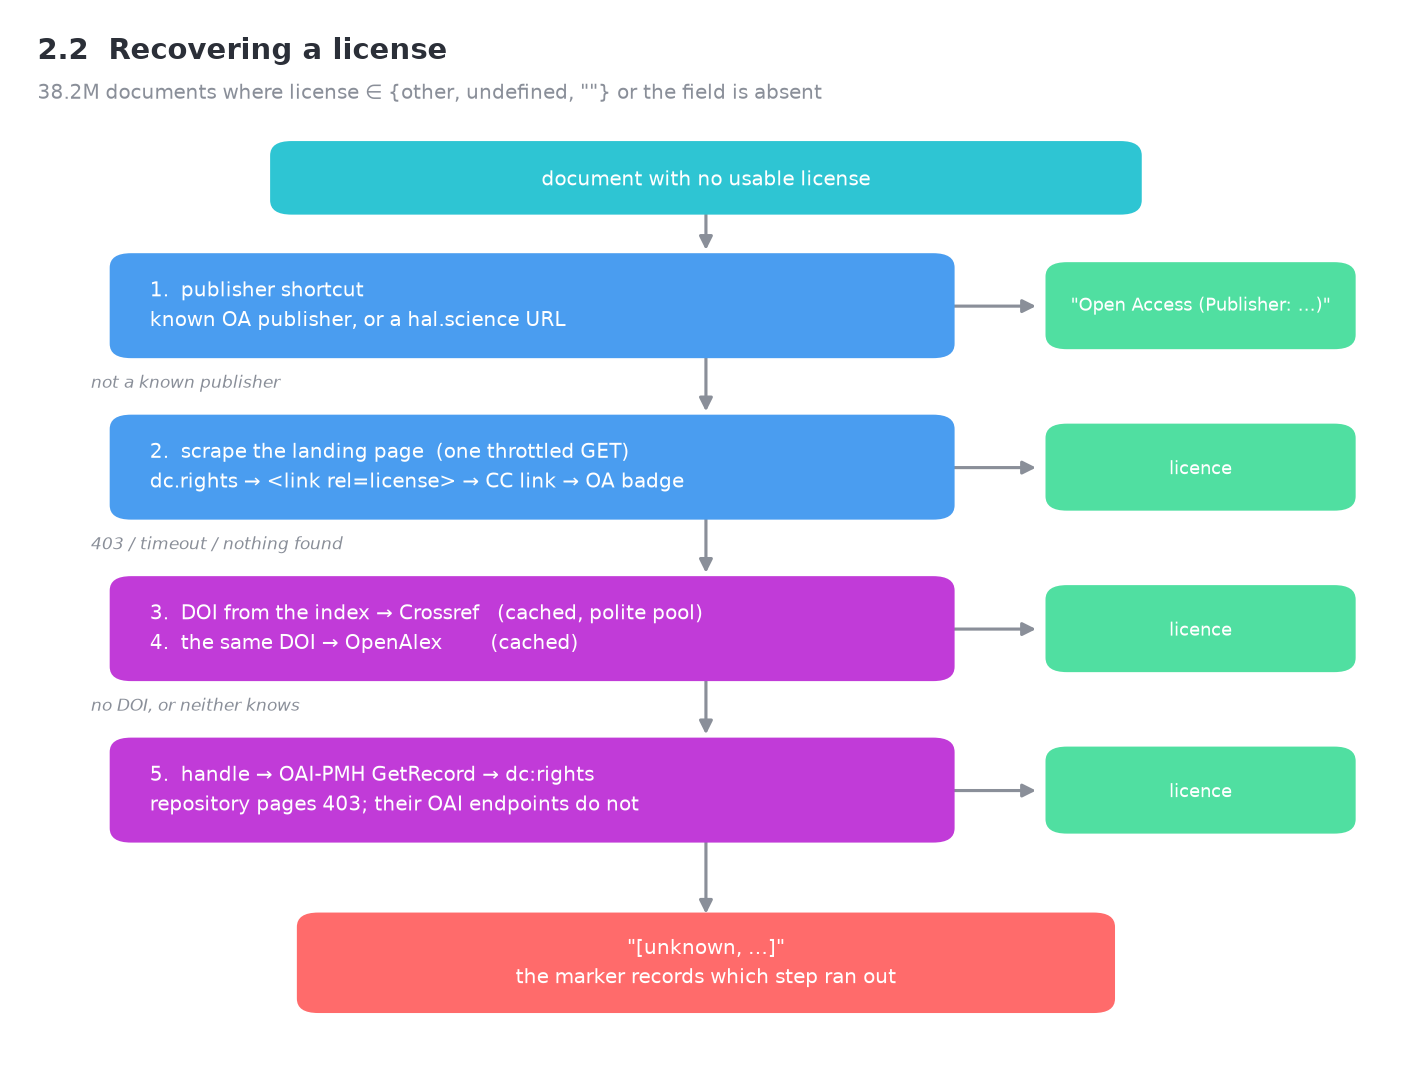

Steps 3–5 exist because scraping fails so often: **12.8% of landing pages answer
403**, concentrated in Cloudflare-protected hosts (doaj.org, hdl.handle.net,
ncbi, cairn). A realistic User-Agent recovered only 1 of 51 — these are
infrastructure blocks, not bot-sniffing — so the fix was to stop scraping those
and ask the metadata APIs instead, which lifted 403 recovery to 57% and overall recovery from 63.5% to 69%.

## 2.3 Run

In [ ]:
params(task="license recovery", index="triple-documents-prod", source="elastic",
       selection='license in {other, undefined, ""} or absent',
       records_requested=DOCUMENT_SAMPLE, population=f"{count_elastic_documents('unresolved'):,}",
       max_workers=10)

with timed("2.3 licenses"):
    _, output = quietly(pipelines.run_license_pipeline,
                        num_docs=str(DOCUMENT_SAMPLE), source="elastic", max_workers=10)

show_query("documents", "\nselection query")
print()
digest(output)

In [ ]:
licenses = pd.read_excel("data/output/license_fix_elastic.xlsx")
result = licenses["scrapped_license"].astype(str)
searched = result[result != "Already classified"]
found = searched[~searched.str.startswith("[unknown")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["recovered", "still unknown"], [len(found), len(searched) - len(found)], color=[OK, BAD])
axes[0].set_title(f"License recovery on {len(searched)} documents")
axes[0].set_ylabel("documents")
for i, v in enumerate([len(found), len(searched) - len(found)]):
    axes[0].text(i, v, f" {v} ({100*v/len(searched):.0f}%)", ha="center", va="bottom")

reasons = searched[searched.str.startswith("[unknown")].value_counts().head(6)[::-1]
if len(reasons):
    axes[1].barh([r.strip("[]").replace("unknown, ", "")[:34] for r in reasons.index],
                 reasons.values, color=BAD)
axes[1].set_title("Why the rest failed")
axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [ ]:
result = pd.read_excel("data/output/license_fix_elastic.xlsx")["scrapped_license"].astype(str)
searched = result[result != "Already classified"]
unknown = searched[searched.str.startswith("[unknown")]
no_license = int(unknown.str.contains("no obvious license").sum())
stage_outcomes([
    ("license recovered", len(searched) - len(unknown), "solved"),
    ("no license anywhere on the page", no_license, "open"),
    ("blocked, timed out, or no usable URL", len(unknown) - no_license, "open"),
], "2.3  What the run settled", f"{len(searched):,} documents that had no usable license")

---
# 3. How long each solution takes

Measured on this run: `AUTHOR_SAMPLE` profiles for §1, `DOCUMENT_SAMPLE` documents for §2.

In [ ]:
summary = pd.DataFrame({"solution": list(TIMINGS), "seconds": [round(v, 1) for v in TIMINGS.values()]})
summary["records"] = [DOCUMENT_SAMPLE if s.startswith("2.") else AUTHOR_SAMPLE for s in summary["solution"]]
summary["per record (s)"] = (summary["seconds"] / summary["records"]).round(3)
summary["1,000 records"] = (summary["per record (s)"] * 1000 / 60).round(1).astype(str) + " min"
display(summary)

fig, ax = plt.subplots()
ordered = summary.sort_values("seconds")
ax.barh(ordered["solution"], ordered["seconds"], color=OK)
ax.set_xlabel(f"seconds for {AUTHOR_SAMPLE} author / {DOCUMENT_SAMPLE} document records"); ax.set_title("Wall-clock cost per solution")
ax.grid(axis="y", visible=False)
for i, v in enumerate(ordered["seconds"]):
    ax.text(v, i, f" {v:.0f}s", va="center")
plt.tight_layout(); plt.show()

### What dominates each timing

| solution | the slow part |
|---|---|
| 1.1 orcid inside | one `pub.orcid.org` request per profile (~0.16s each, incl. a deliberate 0.1s spacing) |
| 1.2 / 1.3 empty, junk | one batched documents query for the whole set, then the same per-profile API pass — except the bare numbers, which the batched query settles outright |
| 1.4 disambiguation | phase 1 is per-profile HTTP; phase 2 is CPU-only and compares every pair |
| 2.3 licenses | one HTTP GET per landing page, throttled per host, plus the Crossref/OpenAlex fallbacks |

**Only phase 2 of clustering grows non-linearly.** It is O(n²) in the number of
records, so 10× the records is ~100× the clustering work. Everything else is
linear and I/O-bound, which also means it responds to more concurrency rather
than faster code.

In [ ]:
per_record = TIMINGS["2.3 licenses"] / DOCUMENT_SAMPLE
population = count_elastic_documents("unresolved")

show_markdown(
    f"Projecting the full population from the timings above: at {per_record:.3f}s a document, the "
    f"{population:,} unresolved documents come to **about {population * per_record / 86400:,.0f} days** "
    "of wall clock. That job has to be scoped by provider or license value rather than run end to end; "
    "the author name-repair jobs, by contrast, are minutes to hours.")